# Curb Conflict Atlas

## tl;dr

This first release analyzes **120 episodes across 12 seasons** using public TVmaze metadata and short synopses.

- **Season 7** has the highest mean episode rating (8.77).
- **Denise Handicapped (S07E05)** is the highest-rated episode in the snapshot (9.4).
- **Relationships & loyalty** is the most common primary synopsis theme (35 episodes).
- The synopsis friction score has only a **weak rank correlation with rating** (Spearman ρ = 0.08). More friction language does not, by itself, identify a better-rated episode.

The taxonomy and friction score are transparent heuristics for synopsis wording. They are not scene-level ground truth.

## Context & Methods

The project asks: *How does ordinary social friction appear in Curb episode descriptions, and is that wording associated with audience ratings?*

### Key assumptions

1. TVmaze episode synopses are sufficient for a lightweight first-pass taxonomy, but not for claims about full scripts or scene structure.
2. TVmaze ratings are observational and mutable; no causal interpretation is appropriate.
3. The keyword taxonomy is intentionally inspectable. Every category and trigger term is saved in `data/rule_taxonomy.csv`.
4. Full transcripts are excluded from the repository to avoid redistributing copyrighted text.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
features = pd.read_csv(ROOT / "outputs" / "episode_features.csv")
edges = pd.read_csv(ROOT / "outputs" / "character_edges.csv")
taxonomy = pd.read_csv(ROOT / "data" / "rule_taxonomy.csv")
metrics = json.loads((ROOT / "outputs" / "metrics.json").read_text())

pd.set_option("display.max_colwidth", 80)

## Data

One row represents one regular episode. The source snapshot and retrieval timestamp are preserved in `data/` and each episode retains its TVmaze URL.

In [2]:
quality_summary = pd.Series({
    "rows": len(features),
    "unique_episode_ids": features["episode_id"].nunique(),
    "seasons": features["season"].nunique(),
    "missing_summaries": features["summary"].isna().sum() + features["summary"].eq("").sum(),
    "missing_ratings": features["rating"].isna().sum(),
    "duplicate_season_episode_keys": features.duplicated(["season", "episode"]).sum(),
})
quality_summary.to_frame("value")

,value
rows,120
unique_episode_ids,120
seasons,12
missing_summaries,0
missing_ratings,0
duplicate_season_episode_keys,0


In [3]:
features[[
    "episode_code", "title", "airdate", "rating", "primary_rule_theme",
    "synopsis_friction_score", "summary"
]].head(5)

,episode_code,title,airdate,rating,primary_rule_theme,synopsis_friction_score,summary
0,S01E01,The Pants Tent,2000-10-15,7.3,Relationships & loyalty,81.32,"Larry's baggy new pants create awkward misunderstandings among Larry, Cheryl..."
1,S01E02,Ted and Mary,2000-10-22,7.3,Relationships & loyalty,36.64,Larry and Cheryl enjoy their bowling double-date with Ted Danson and Mary St...
2,S01E03,Porno Gil,2000-10-29,7.5,Space & access,79.00,By not picking up a golf ball that drops out of a bucket carried by a man in...
3,S01E04,The Bracelet,2000-11-05,7.1,Money & exchange,66.00,"Larry wants to buy a bracelet for Cheryl, but he is not buzzed into the stor..."
4,S01E05,Interior Decorator,2000-11-12,7.5,Space & access,51.00,"By politely holding the elevator door for a woman in an office building, Lar..."


## Results

### 1. Ratings across the series

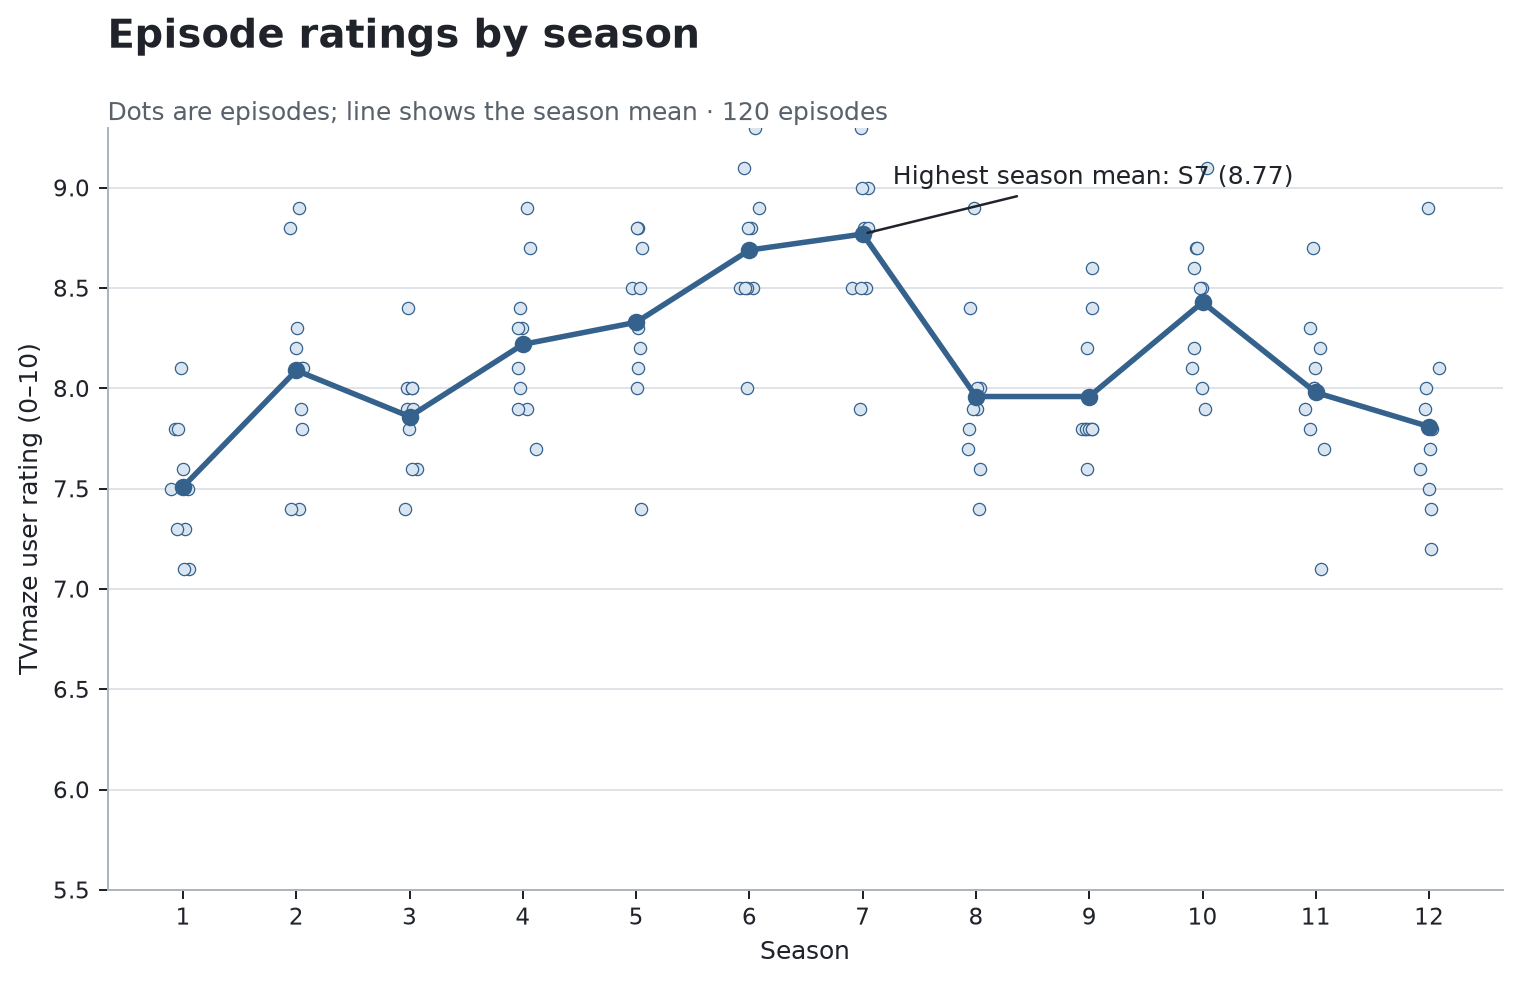

In [4]:
display(Image(filename=ROOT / 'outputs' / 'charts' / 'season_ratings.png', width=950))

In [5]:
season_summary = features.groupby("season").agg(
    episodes=("episode_id", "size"),
    mean_rating=("rating", "mean"),
    median_rating=("rating", "median"),
    min_rating=("rating", "min"),
    max_rating=("rating", "max"),
).round(2)
season_summary

,episodes,mean_rating,median_rating,min_rating,max_rating
season,,,,,
1,10,7.51,7.50,7.1,8.1
2,10,8.09,8.10,7.4,8.9
3,10,7.86,7.90,7.4,8.4
4,10,8.22,8.20,7.7,8.9
5,10,8.33,8.40,7.4,8.8
6,10,8.69,8.65,8.0,9.3
7,10,8.77,8.80,7.9,9.4
8,10,7.96,7.90,7.4,8.9
9,10,7.96,7.80,7.6,8.6


### 2. Which social-rule themes appear most often?

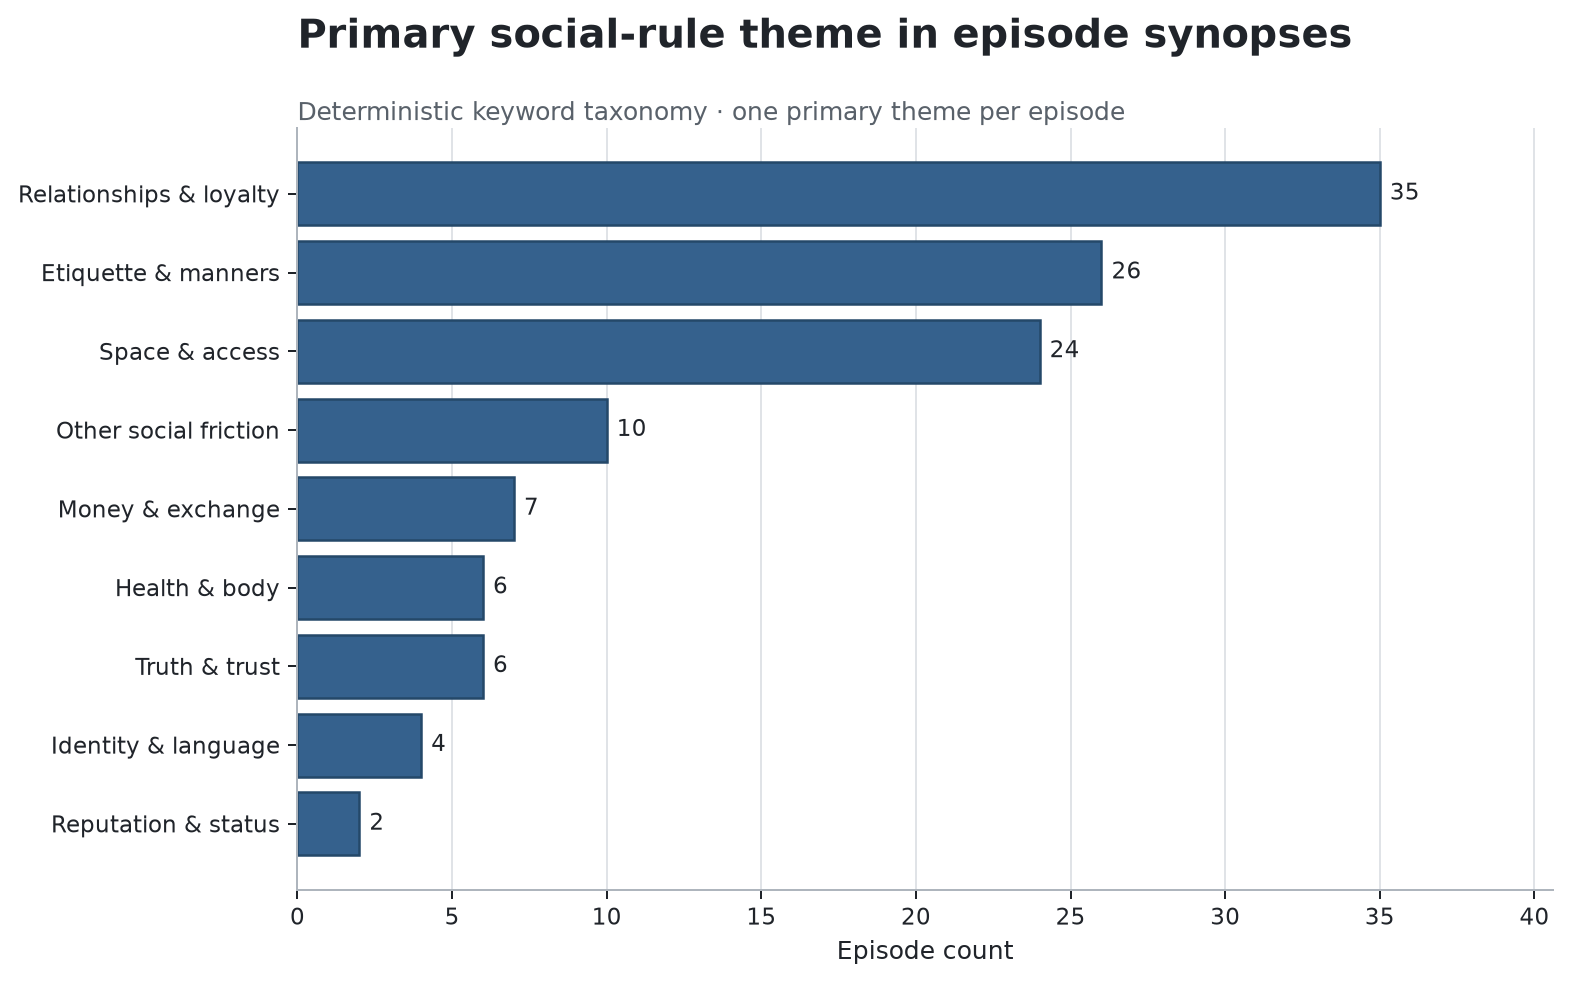

In [6]:
display(Image(filename=ROOT / 'outputs' / 'charts' / 'rule_theme_distribution.png', width=900))

In [7]:
taxonomy

,category,keywords
0,Etiquette & manners,"apology, apologize, birthday, dinner, etiquette, funeral, gift, guest, invit..."
1,Truth & trust,"accuse, alibi, betray, deceive, hide, lie, lying, promise, rumor, secret, su..."
2,Space & access,"airplane, bathroom, car, club, elevator, golf, hotel, line, office, park, pa..."
3,Relationships & loyalty,"affair, boyfriend, cheryl, date, dating, divorce, family, friend, girlfriend..."
4,Identity & language,"accent, black, christian, culture, disability, gay, handicap, identity, isra..."
5,Money & exchange,"bill, business, buy, contract, debt, donation, job, loan, money, pay, paymen..."
6,Health & body,"body, death, dentist, doctor, funeral, health, heart, hospital, illness, inj..."
7,Reputation & status,"celebrity, credit, embarrass, famous, hero, honor, insult, offend, reputatio..."


### 3. Does more synopsis friction mean a higher rating?

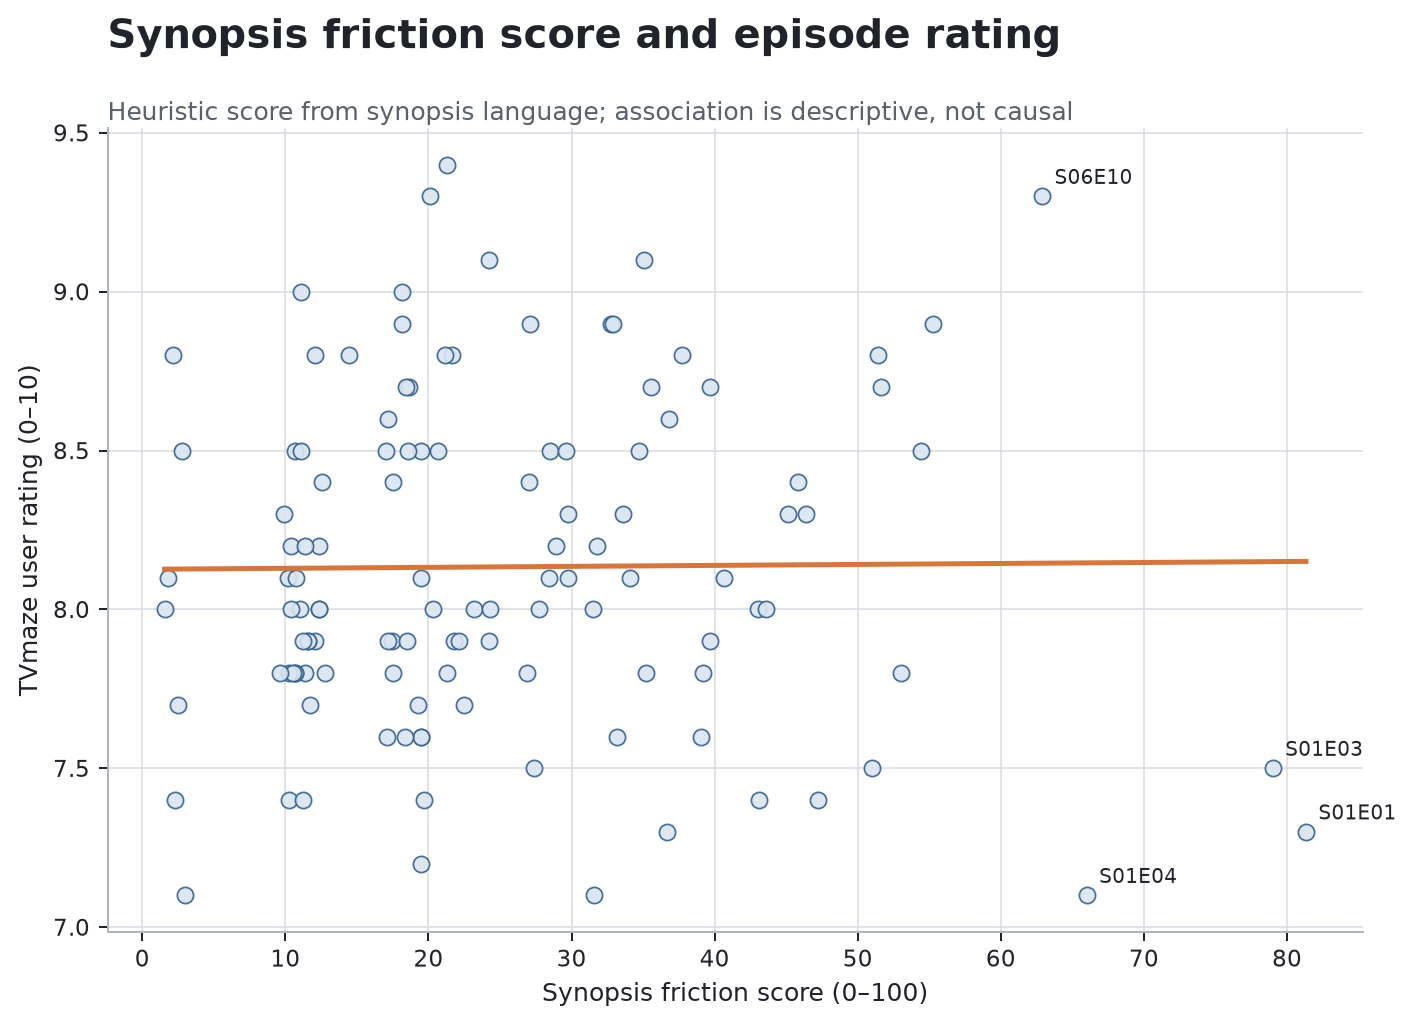

In [8]:
display(Image(filename=ROOT / 'outputs' / 'charts' / 'friction_vs_rating.png', width=900))

In [9]:
top_friction = features.nlargest(10, "synopsis_friction_score")[[
    "episode_code", "title", "synopsis_friction_score", "rating", "primary_rule_theme"
]]
top_friction

,episode_code,title,synopsis_friction_score,rating,primary_rule_theme
0,S01E01,The Pants Tent,81.32,7.3,Relationships & loyalty
2,S01E03,Porno Gil,79.00,7.5,Space & access
3,S01E04,The Bracelet,66.00,7.1,Money & exchange
59,S06E10,The Bat Mitzvah,62.88,9.3,Truth & trust
57,S06E08,The N Word,55.24,8.9,Health & body
51,S06E02,The Anonymous Donor,54.44,8.5,Truth & trust
18,S02E09,The Baptism,53.00,7.8,Identity & language
46,S05E07,The Seder,51.64,8.7,Etiquette & manners
50,S06E01,Meet The Blacks,51.40,8.8,Relationships & loyalty
4,S01E05,Interior Decorator,51.00,7.5,Space & access


Spearman's rank correlation is **0.08**, which is too small to support a meaningful monotonic association in this snapshot. This is a useful constraint on the story: synopsis wording alone is not a rating model.

### 4. Which characters are co-mentioned?

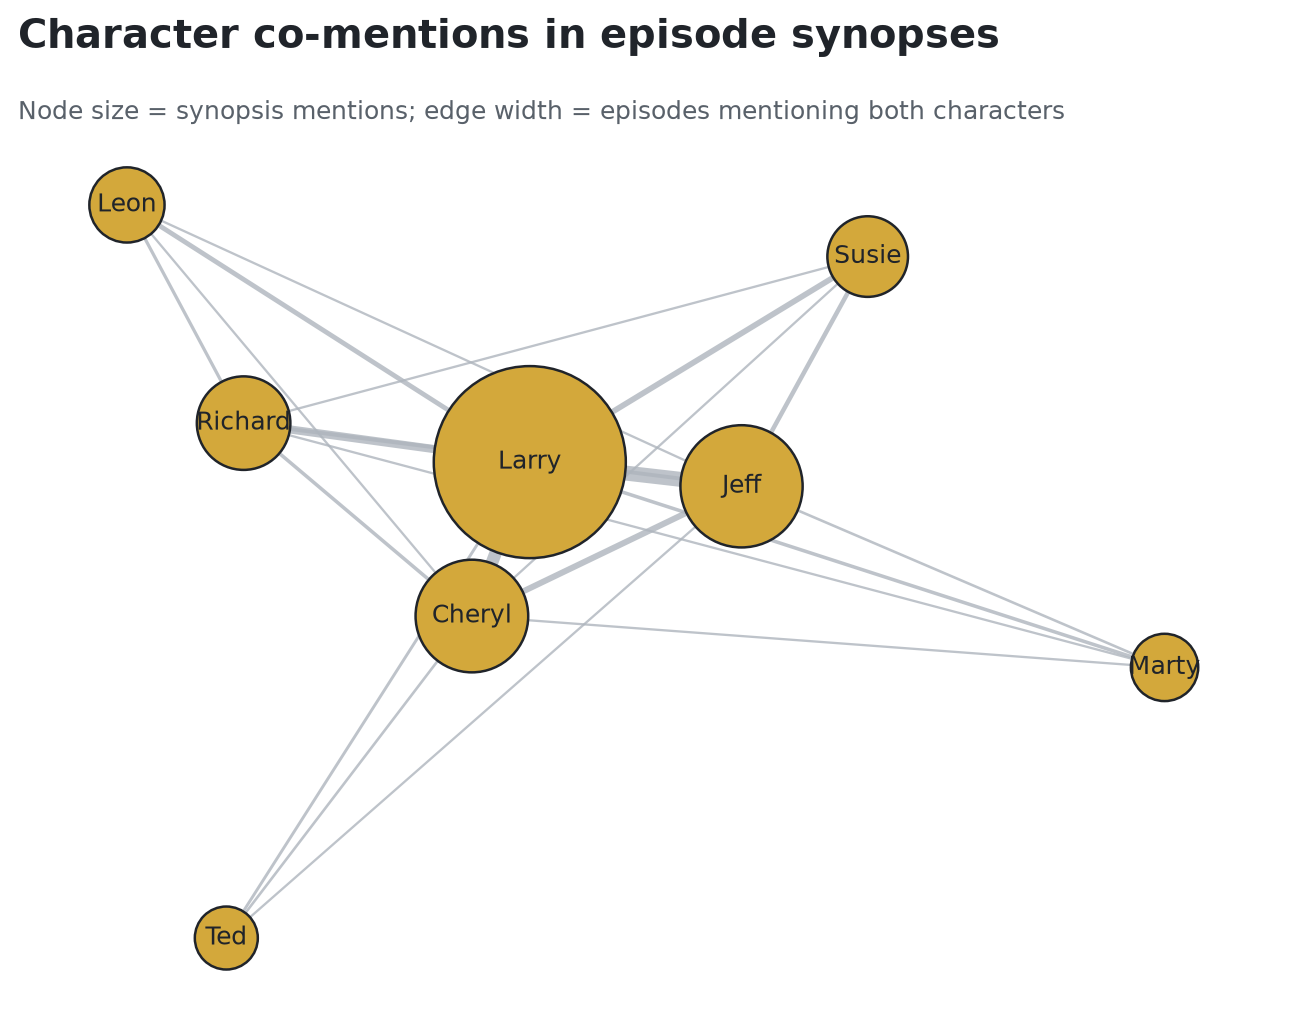

In [10]:
display(Image(filename=ROOT / 'outputs' / 'charts' / 'character_network.png', width=900))

In [11]:
edges.head(12)

,source,target,episode_count
0,Larry,Jeff,42
1,Larry,Cheryl,34
2,Larry,Richard,20
3,Cheryl,Jeff,13
4,Larry,Susie,12
5,Larry,Leon,9
6,Jeff,Susie,8
7,Jeff,Richard,6
8,Cheryl,Richard,5
9,Larry,Marty,5


## Takeaways

1. The source snapshot is complete for the intended scope: **120 unique regular episodes**, no missing summaries or ratings, and no duplicate season/episode keys.
2. **Season 7** is the strongest-rated season on average in this TVmaze snapshot.
3. Synopsis themes lean toward **relationships, loyalty, etiquette, and access to spaces**—a useful starting taxonomy for later scene-level annotation.
4. The friction heuristic should remain descriptive. Its weak relationship with ratings suggests that future work should add richer structure: who initiates a dispute, whether Larry is vindicated, escalation steps, callbacks, and guest-star context.
5. Character links are synopsis co-mentions, not proof that two characters share a scene.

### Next release

Build a small, manually reviewed scene annotation set with `rule_broken`, `initiator`, `target`, `escalation_steps`, `larry_vindicated`, and `callback_present`. That will enable the real **Larry Vindication Score** without pretending keyword matches are ground truth.